# Dataset Analysis, Feature Selection & Transformation

Input: preprocessed data `data/processed/ml_train.csv` and `data/processed/ml_test.csv`.

Output: feature engineered data `data/processed/features_train.csv`, `data/processed/features_test.csv`, and a saved `data/processed/preprocessing_objects.joblib` (the fitted encoder + scaler).

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
import joblib

from helpers.nb_utils import (
    quick_summary, plot_missingness, plot_boxplot_by_class, plot_class_counts,
    PROC_DIR, FIG_DIR,
)

pd.set_option("display.max_columns", 50)

## 1. Load the engineered data

In [17]:
train = pd.read_csv(PROC_DIR / "ml_train.csv")
test = pd.read_csv(PROC_DIR / "ml_test.csv")

quick_summary(train, "Training set")
quick_summary(test, "Testing set")

--- Training set ---
shape: (663, 13)


,country,cca3,reference_year,population_at_reference,density_at_reference,population_growth_prior_decade_pct,prior_decade_mean_temp_c,prior_decade_warming_c_per_decade,prior_decade_volatility_c,prior_decade_uncertainty_c,area_km2,continent,target_exposure_class
0,Aruba,ABW,1970,59106,328.366667,NaN,28.199408,0.107460,0.189841,0.358767,180,North America,High
1,Aruba,ABW,1980,62267,345.927778,5.348019,28.167542,0.197955,0.287829,0.327217,180,North America,Low
2,Aruba,ABW,1990,65712,365.066667,5.532626,28.342575,-0.270318,0.302661,0.324258,180,North America,High


columns with missing values (%):


population_growth_prior_decade_pct    33.33
dtype: float64

--- Testing set ---
shape: (221, 13)


,country,cca3,reference_year,population_at_reference,density_at_reference,population_growth_prior_decade_pct,prior_decade_mean_temp_c,prior_decade_warming_c_per_decade,prior_decade_volatility_c,prior_decade_uncertainty_c,area_km2,continent,target_exposure_class
0,Aruba,ABW,2000,89101,495.005556,35.593195,28.531633,0.322152,0.224315,0.317167,180,North America,High
1,Afghanistan,AFG,2000,19542982,29.963329,82.733565,14.732458,0.799712,0.324100,0.451775,652230,Asia,Low
2,Angola,AGO,2000,16394062,13.149966,38.596362,22.477567,0.413253,0.294703,0.494600,1246700,Africa,Low


## 2. Missing values

Only `population_growth_prior_decade_pct` has missing values, and only in training. Checking
*where* they occur (not just how many) explains why: this feature needs a population figure
from ten years earlier, and the dataset's earliest snapshot is 1970 — so every row using 1970 as
its reference year has no prior decade to compute growth from. It is missing for a structural
reason, not a data-quality problem, and it is 100% of the 1970 rows, not a random scatter.

What we did was instead of dropping these ~221 rows, we filled the missing value with the training median growth rate and added an explicit `population_growth_is_estimated` flag, so the tree-based models can understand that.

Share of rows missing population_growth_prior_decade_pct, by reference year:
reference_year
1970    1.0
1980    0.0
1990    0.0
Name: population_growth_prior_decade_pct, dtype: float64


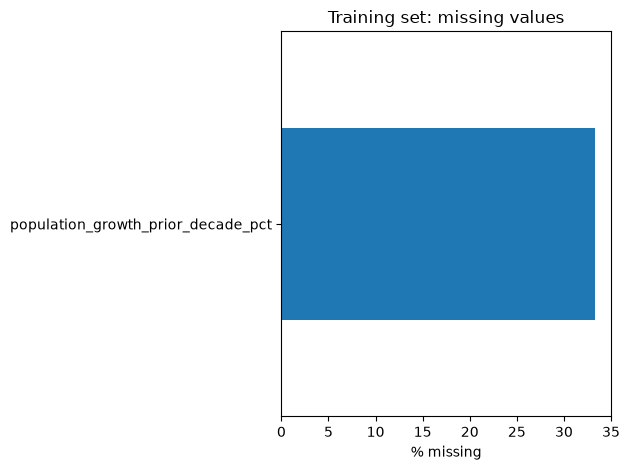


Training median growth rate used for imputation: 22.27%


In [18]:
missing_by_year = train.groupby("reference_year")["population_growth_prior_decade_pct"].apply(lambda s: s.isna().mean())
print("Share of rows missing population_growth_prior_decade_pct, by reference year:")
print(missing_by_year)

plot_missingness(train, "Training set: missing values")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_missing_values.png", dpi=200)
plt.show()

growth_median = train["population_growth_prior_decade_pct"].median()
print(f"\nTraining median growth rate used for imputation: {growth_median:.2f}%")

for df in (train, test):
    df["population_growth_is_estimated"] = df["population_growth_prior_decade_pct"].isna().astype(int)
    df["population_growth_prior_decade_pct"] = df["population_growth_prior_decade_pct"].fillna(growth_median)

## 3. Class balance

The Low/Medium/High cutoffs were fixed using only the training years, then applied unchanged to
the test year. That is deliberately realistic, but it means the test set's class balance is
whatever naturally falls out of that fixed boundary — not necessarily even.

Training class counts: {'High': 221, 'Low': 221, 'Medium': 221}
Testing class counts: {'Medium': 93, 'High': 66, 'Low': 62}


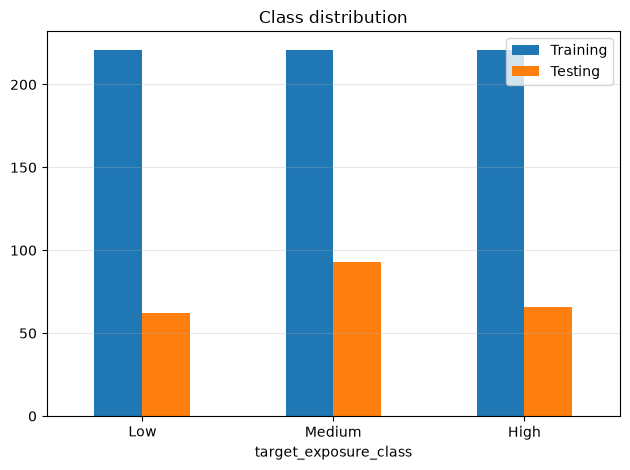

In [19]:
print("Training class counts:", train["target_exposure_class"].value_counts().to_dict())
print("Testing class counts:", test["target_exposure_class"].value_counts().to_dict())

plot_class_counts(train["target_exposure_class"], test["target_exposure_class"])
plt.tight_layout()
plt.savefig(FIG_DIR / "09_class_balance.png", dpi=200)
plt.show()

## 4. Do the features actually separate the classes?

Before running any formal feature-selection statistic, a quick visual check: for each numeric
feature, does its spread actually differ across Low/Medium/High? A feature that looks identical
across all three classes is unlikely to help any of the four models, however it scores on paper.

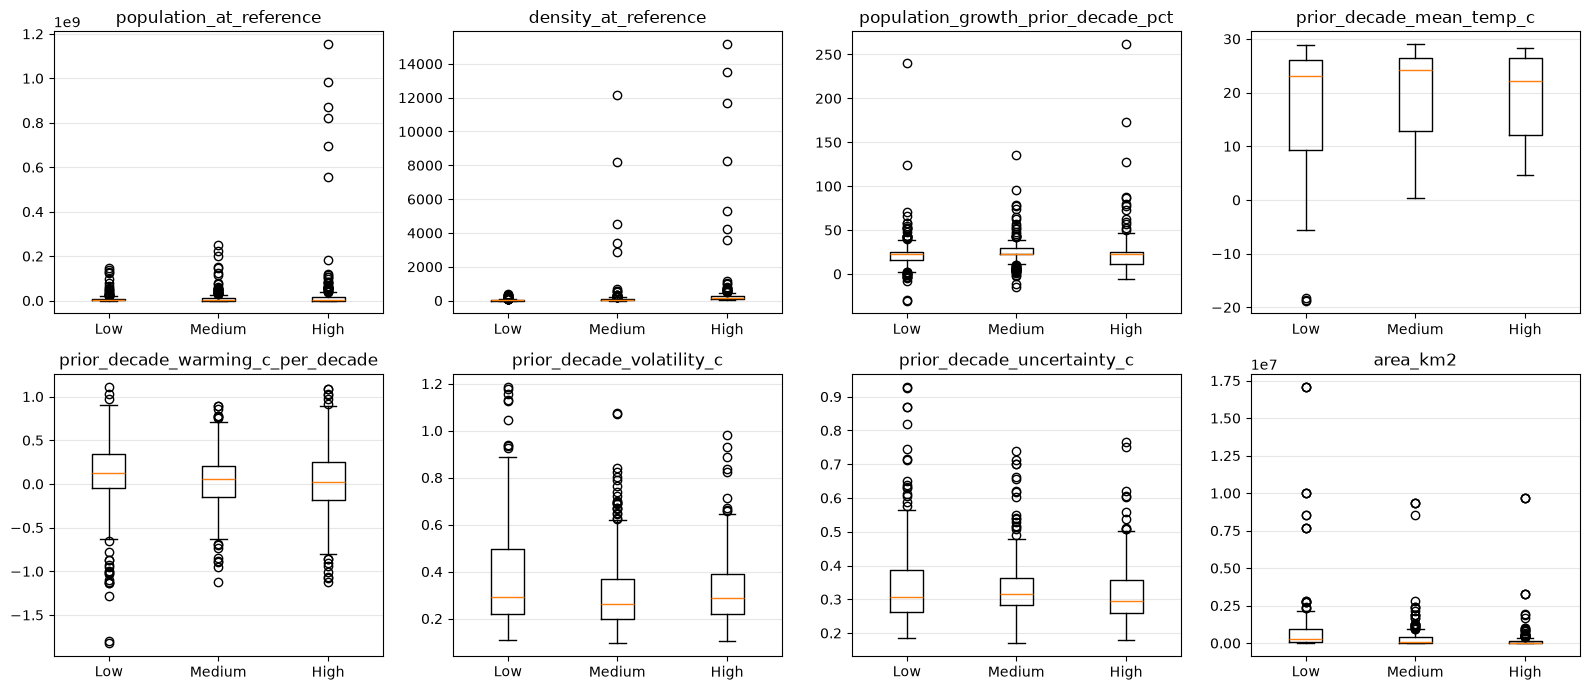

In [20]:
numeric_features = [
    "population_at_reference", "density_at_reference", "population_growth_prior_decade_pct",
    "prior_decade_mean_temp_c", "prior_decade_warming_c_per_decade",
    "prior_decade_volatility_c", "prior_decade_uncertainty_c", "area_km2",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for feature, ax in zip(numeric_features, axes.ravel()):
    plot_boxplot_by_class(train, feature, ax=ax, title=feature)
plt.tight_layout()
plt.savefig(FIG_DIR / "10_feature_separation.png", dpi=200)
plt.show()

## 5. Continent: a real category, encoded without inventing an order

Continent is nominal — "Asia" is not more or less than "Europe" — so it's one-hot encoded rather
than mapped to arbitrary integers, which would falsely imply an ordering to any model that
doesn't already understand it's categorical (Naïve Bayes and the ANN in particular).

The encoder is **fit on the training continents only** and reused on test with
`handle_unknown="ignore"`, so if a continent value ever appeared in test but not training, it
would produce all-zero indicator columns rather than crash the pipeline.

In [21]:
print(train["continent"].value_counts())

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(train[["continent"]])

continent_cols = list(encoder.get_feature_names_out(["continent"]))
train_continent = pd.DataFrame(encoder.transform(train[["continent"]]), columns=continent_cols, index=train.index)
test_continent = pd.DataFrame(encoder.transform(test[["continent"]]), columns=continent_cols, index=test.index)

continent
Africa           168
Asia             144
Europe           144
North America    117
Oceania           48
South America     42
Name: count, dtype: int64


## 6. Correlation check: is any feature redundant?

Two pairs were worth checking specifically, because they *sound* like they could be redundant
before you actually look:

- `area_km2` and `density_at_reference` — density is literally computed from population and
  area, so it's reasonable to expect them to move together. **They don't**: the correlation
  turns out to be essentially zero (see heatmap), because population itself varies far more than
  area does across countries. Both are kept.
- `prior_decade_mean_temp_c` and `prior_decade_volatility_c` — these show a real, moderate
  negative correlation (around −0.7): countries with warmer average climates tend to have less
  year-to-year temperature swing. That's an expected physical relationship (tropical climates
  are more thermally stable than temperate ones), not a data error, and it's mild enough that
  it doesn't warrant dropping either feature — a decision tree or random forest can still split
  on both, and Naïve Bayes' independence assumption is an approximation everywhere in this
  dataset, not uniquely broken here.

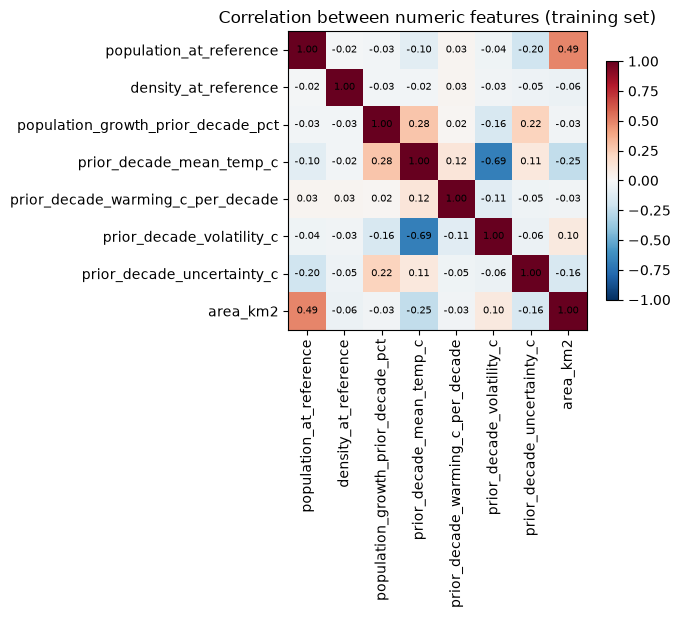

In [22]:
corr = train[numeric_features].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(numeric_features)))
ax.set_xticklabels(numeric_features, rotation=90)
ax.set_yticks(range(len(numeric_features)))
ax.set_yticklabels(numeric_features)
for i in range(len(numeric_features)):
    for j in range(len(numeric_features)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, shrink=0.8)
ax.set_title("Correlation between numeric features (training set)")
plt.tight_layout()
plt.savefig(FIG_DIR / "11_correlation_heatmap.png", dpi=200)
plt.show()

## 7. Formal feature selection: mutual information

This is the technique from the Week 7 feature-selection lecture applied here: mutual information
measures how much knowing a feature reduces uncertainty about the class, works for both
continuous and encoded categorical columns without assuming a linear relationship (unlike a
correlation-based filter), and needs no distributional assumption.

With only 8 raw predictors (plus 6 one-hot continent columns) and a training set
of this size, there isn't a strong case for discarding any of them outright — the risk of
throwing away a genuinely useful signal outweighs the benefit of a smaller feature set. The
ranking below is used descriptively, to report in the presentation which features carry the most
signal, rather than to prune the feature set.

density_at_reference                  0.355
area_km2                              0.124
prior_decade_mean_temp_c              0.084
prior_decade_volatility_c             0.080
continent_Africa                      0.066
prior_decade_warming_c_per_decade     0.056
population_at_reference               0.050
continent_Asia                        0.043
continent_North America               0.024
continent_South America               0.023
population_growth_is_estimated        0.022
prior_decade_uncertainty_c            0.016
population_growth_prior_decade_pct    0.000
continent_Europe                      0.000
continent_Oceania                     0.000
dtype: float64


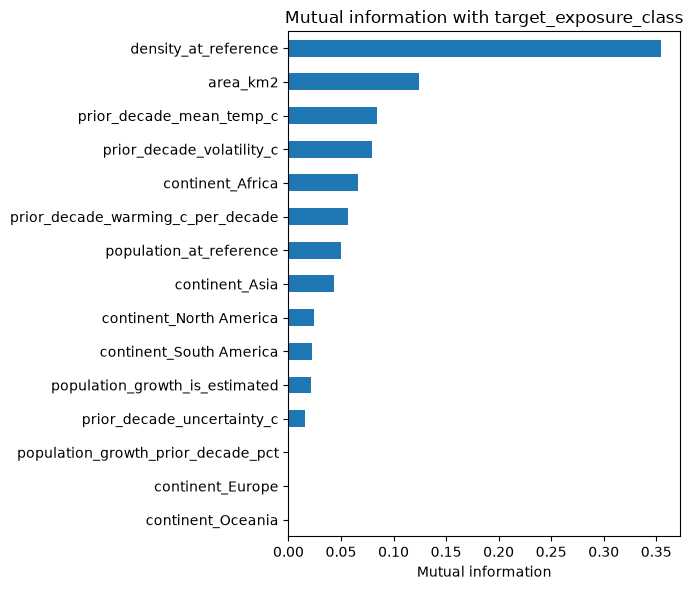

In [23]:
X_train_full = pd.concat([train[numeric_features + ["population_growth_is_estimated"]], train_continent], axis=1)
y_train = train["target_exposure_class"]

mi_scores = mutual_info_classif(X_train_full, y_train, discrete_features=False, random_state=42)
mi_ranking = pd.Series(mi_scores, index=X_train_full.columns).sort_values(ascending=False)

print(mi_ranking.round(3))
mi_ranking.plot(kind="barh", figsize=(7, 6), title="Mutual information with target_exposure_class")
plt.gca().invert_yaxis()
plt.xlabel("Mutual information")
plt.tight_layout()
plt.savefig(FIG_DIR / "12_mutual_information.png", dpi=200)
plt.show()

## 8. Scaling

Decision Tree and Random Forest split on raw thresholds and don't care about feature scale, but
the ANN's gradient-based training and Naïve Bayes' variance estimates both do — a feature
measured in hundreds of millions (population) would otherwise dominate one measured in single
percentage points (growth rate) for reasons that have nothing to do with actual importance.

One shared `StandardScaler`, **fit on training data only**, is used for every model that needs
it, so all four models are compared on the same feature representation rather than each rescaling things its own way.

In [24]:
scaler = StandardScaler()
scaler.fit(X_train_full[numeric_features])

def build_feature_matrix(base_df, continent_df):
    scaled = pd.DataFrame(
        scaler.transform(base_df[numeric_features]), columns=numeric_features, index=base_df.index
    )
    out = pd.concat([
        base_df[["country", "cca3", "reference_year"]],
        scaled,
        base_df[["population_growth_is_estimated"]],
        continent_df,
        base_df[["target_exposure_class"]],
    ], axis=1)
    return out

features_train = build_feature_matrix(train, train_continent)
features_test = build_feature_matrix(test, test_continent)

print(features_train.shape, features_test.shape)
features_train.head()

(663, 19) (221, 19)


,country,cca3,reference_year,population_at_reference,density_at_reference,population_growth_prior_decade_pct,prior_decade_mean_temp_c,prior_decade_warming_c_per_decade,prior_decade_volatility_c,prior_decade_uncertainty_c,area_km2,population_growth_is_estimated,continent_Africa,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,target_exposure_class
0,Aruba,ABW,1970,-0.236249,0.074328,-0.072359,1.025979,0.132693,-0.792447,0.227993,-0.339623,1,0.0,0.0,0.0,1.0,0.0,0.0,High
1,Aruba,ABW,1980,-0.236212,0.089295,-0.876533,1.022263,0.354008,-0.283207,-0.057346,-0.339623,0,0.0,0.0,0.0,1.0,0.0,0.0,Low
2,Aruba,ABW,1990,-0.236171,0.105608,-0.867759,1.042676,-0.791201,-0.206131,-0.084101,-0.339623,0,0.0,0.0,0.0,1.0,0.0,0.0,High
3,Afghanistan,AFG,1970,-0.111223,-0.191495,-0.072359,-0.634548,-0.919002,0.789421,0.709285,0.021881,1,0.0,1.0,0.0,0.0,0.0,0.0,Low
4,Afghanistan,AFG,1980,-0.090954,-0.189229,-0.364446,-0.625836,0.136090,2.101061,0.714184,0.021881,0,0.0,1.0,0.0,0.0,0.0,0.0,Low


## 9. Save everything the modelling notebooks need

Saving the fitted encoder and scaler alongside the transformed data means every later notebook
applies the *exact same* transformation — there's no risk of the Random Forest notebook and the
ANN notebook silently using two slightly different encodings of continent.

In [ ]:
features_train.to_csv(PROC_DIR / "features_train.csv", index=False)
features_test.to_csv(PROC_DIR / "features_test.csv", index=False)

Saved features_train.csv, features_test.csv and preprocessing_objects.joblib to /Users/macrosh/Documents/Masters/3rd Sem/Machine Learning/Assessment_3/data/processed
